# Deep Learning Models with PCA Optimization
## Phase 2: Optimization - Dimensionality Reduction

### Optimization Technique:
**PCA (Principal Component Analysis)** - Same method used for ML models

### Method:
1. Standardize features (StandardScaler)
2. Apply PCA to reduce dimensions from 57 to 30 components
3. Train models on PCA-transformed features

### Models:
1. CNN (Convolutional Neural Network)
2. LSTM (Long Short-Term Memory)

## 1️⃣ Import Libraries

In [2]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import (Dense, Dropout, Conv1D, MaxPooling1D, Flatten,
                          LSTM, BatchNormalization)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"\n🔧 TensorFlow version: {tf.__version__}")
print(f"🖥️ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ All libraries imported successfully!

🔧 TensorFlow version: 2.20.0
🖥️ GPU available: False


## 2️⃣ Configuration

In [3]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/dl_optimized/pca/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PCA CONFIGURATION (SAME AS ML MODELS)
# ========================================
N_COMPONENTS = 30  # Reduce 57 features to 30 principal components

print(f"🎯 PCA Configuration: {N_COMPONENTS} components")

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================
# Using stratified sampling to preserve class distribution

MODEL_SAMPLE_SIZES = {
    'CNN': 1000000,      # Use 1M rows for CNN
    'LSTM': 500000       # Use 500k rows for LSTM (slower to train)
}

print(f"\n📊 Per-Model Sample Sizes (with stratified sampling):")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    print(f"   {model}: {size_str}")

# ========================================
# DEEP LEARNING SPECIFIC SETTINGS
# ========================================
BATCH_SIZE = 1024
EPOCHS = 30
VALIDATION_SPLIT = 0.1
PATIENCE = 5

print(f"\n🔧 Deep Learning Settings:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Max epochs: {EPOCHS}")
print(f"   Validation split: {VALIDATION_SPLIT}")
print(f"   Early stopping patience: {PATIENCE}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")
print(f"\n🎯 Optimization: PCA (Principal Component Analysis)")

🎯 PCA Configuration: 30 components

📊 Per-Model Sample Sizes (with stratified sampling):
   CNN: 1,000,000 rows
   LSTM: 500,000 rows

🔧 Deep Learning Settings:
   Batch size: 1024
   Max epochs: 30
   Validation split: 0.1
   Early stopping patience: 5

✅ Base model directory: trained_models/dl_optimized/pca/

🎯 Optimization: PCA (Principal Component Analysis)


## 3️⃣ Load Dataset

In [4]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # Load full dataset to see true distribution

chunks = []
total_rows = 0

print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

## 4️⃣ Prepare Features and Target

In [5]:
# ========================================
# SEPARATE FEATURES AND TARGET
# ========================================

label_columns = ['Label', 'Label_Binary']
existing_labels = [col for col in label_columns if col in df_full.columns]

X_full = df_full.drop(columns=existing_labels)
y_full = df_full['Label_Binary']

print(f"✅ Features (X): {X_full.shape}")
print(f"✅ Target (y): {y_full.shape}")
print(f"\n📊 Original features: {X_full.shape[1]}")
print(f"📊 After PCA: {N_COMPONENTS} components (reduction: {X_full.shape[1] - N_COMPONENTS} features)")

# Display class distribution
print(f"\n📊 Full Dataset Class Distribution:")
print(y_full.value_counts())
print(f"\n   Normal (0): {(y_full==0).sum():,} ({(y_full==0).sum()/len(y_full)*100:.2f}%)")
print(f"   Attack (1): {(y_full==1).sum():,} ({(y_full==1).sum()/len(y_full)*100:.2f}%)")

✅ Features (X): (16232943, 57)
✅ Target (y): (16232943,)

📊 Original features: 57
📊 After PCA: 30 components (reduction: 27 features)

📊 Full Dataset Class Distribution:
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64

   Normal (0): 13,484,708 (83.07%)
   Attack (1): 2,748,235 (16.93%)


## 5️⃣ Helper Functions

In [6]:
def calculate_far(y_true, y_pred):
    """Calculate False Alert Rate: FAR = FP / (FP + TN)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return far

def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """Get train/test split with optional stratified sampling"""
    if sample_size is None:
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        if sample_size > len(X_full):
            print(f"⚠️  Requested {sample_size:,} rows but only {len(X_full):,} available")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            X, _, y, _ = train_test_split(
                X_full, y_full, 
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    # Show class distribution after sampling
    print(f"\n📊 Class Distribution in Sample:")
    print(f"   Normal (0): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.2f}%)")
    print(f"   Attack (1): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.2f}%)")
    
    print(f"\n🔪 Splitting into train/test ({test_size*100}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test

def plot_training_history(history, model_name, save_dir):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()

print("✅ Helper functions defined")

✅ Helper functions defined


## 6️⃣ Model 1: CNN with PCA

🚀 TRAINING: CNN WITH PCA
📁 Model directory: trained_models/dl_optimized/pca/cnn\
📊 Sampling 1,000,000 rows from 16,232,943 total (stratified)

📊 Class Distribution in Sample:
   Normal (0): 830,700 (83.07%)
   Attack (1): 169,300 (16.93%)

🔪 Splitting into train/test (20.0% test)...
✅ Train set: 800,000 samples
✅ Test set: 200,000 samples

⚖️  Step 1/2: Standardizing features...
✅ Features standardized: mean=0, std=1

🔬 Step 2/2: Applying PCA...
   Original dimensions: 57
   Reduced dimensions: 30
   Variance explained: 99.94%
   Reduction: 27 features removed
✅ PCA transformation complete
💾 Scaler & PCA saved

✅ CNN input shape: (800000, 30, 1)

🏗️ Building CNN architecture...
✅ CNN model built


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,993 (519.50 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 640 (2.50 KB)


⏱️ Training CNN with PCA-reduced features...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9751 - loss: 0.0955 - val_accuracy: 0.9859 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.9852 - loss: 0.0639 - val_accuracy: 0.9868 - val_loss: 0.0556 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9863 - loss: 0.0592 - val_accuracy: 0.9879 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.9869 - loss: 0.0568 - val_accuracy: 0.9868 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9873 - loss: 0.0556 - val_accuracy: 0.9886 - val_loss: 0.0514 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9875 - loss: 0.0546 - val_accuracy: 0.9885 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━

✅ Predictions completed in 1.54 seconds

📊 RESULTS WITH PCA:
   Accuracy:  0.9890 (98.90%)
   Precision: 0.9948
   Recall:    0.9397
   F1-Score:  0.9665
   FAR:       0.0010 (0.10%)  ⭐ Key Metric!

🕐 TIME:
   Train: 666.18s (11.10 min)
   Test:  1.54s

🎯 Confusion Matrix:
[[165974    166]
 [  2043  31817]]

💾 Model & metadata saved

📈 Plotting training history...


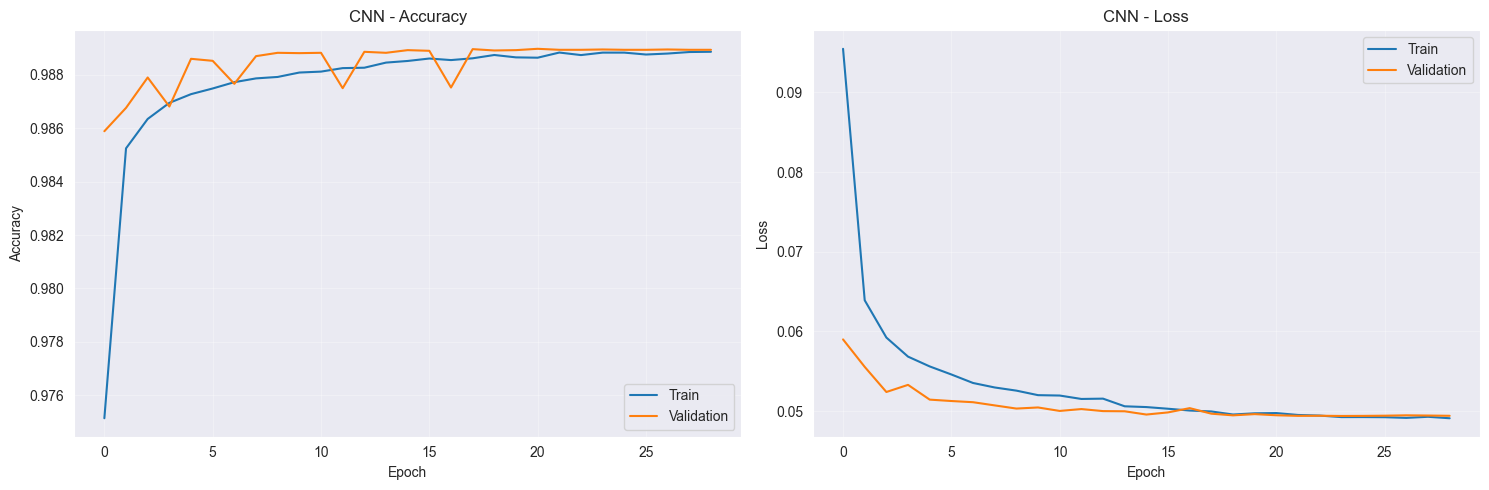

In [7]:
# ========================================
# CNN MODEL WITH PCA
# ========================================

print("="*80)
print("🚀 TRAINING: CNN WITH PCA")
print("="*80)

model_dir = os.path.join(BASE_MODEL_DIR, 'cnn', '')
os.makedirs(model_dir, exist_ok=True)
print(f"📁 Model directory: {model_dir}")

# Get data with stratified sampling
sample_size = MODEL_SAMPLE_SIZES.get('CNN')
X_train, X_test, y_train, y_test = get_model_data(
    X_full, y_full,
    'CNN',
    sample_size,
    TEST_SIZE,
    RANDOM_STATE
)

# ========================================
# STEP 1: STANDARDIZE (Required for PCA)
# ========================================
print(f"\n⚖️  Step 1/2: Standardizing features...")
scaler_cnn = StandardScaler()
X_train_scaled = scaler_cnn.fit_transform(X_train)
X_test_scaled = scaler_cnn.transform(X_test)
print(f"✅ Features standardized: mean=0, std=1")

# ========================================
# STEP 2: APPLY PCA
# ========================================
print(f"\n🔬 Step 2/2: Applying PCA...")
print(f"   Original dimensions: {X_train_scaled.shape[1]}")

pca_cnn = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca_cnn.fit_transform(X_train_scaled)
X_test_pca = pca_cnn.transform(X_test_scaled)

print(f"   Reduced dimensions: {X_train_pca.shape[1]}")
print(f"   Variance explained: {pca_cnn.explained_variance_ratio_.sum()*100:.2f}%")
print(f"   Reduction: {X_train_scaled.shape[1] - X_train_pca.shape[1]} features removed")
print(f"✅ PCA transformation complete")

# Save transformers
if SAVE_MODELS:
    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler_cnn, f)
    with open(os.path.join(model_dir, 'pca.pkl'), 'wb') as f:
        pickle.dump(pca_cnn, f)
    print(f"💾 Scaler & PCA saved")

# Reshape for CNN
X_train_cnn = X_train_pca.reshape(X_train_pca.shape[0], X_train_pca.shape[1], 1)
X_test_cnn = X_test_pca.reshape(X_test_pca.shape[0], X_test_pca.shape[1], 1)
print(f"\n✅ CNN input shape: {X_train_cnn.shape}")

# Build CNN model
print("\n🏗️ Building CNN architecture...")
cnn_model = Sequential([
    # First Conv Block
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(N_COMPONENTS, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Second Conv Block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ CNN model built")
cnn_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# Train
print("\n⏱️ Training CNN with PCA-reduced features...")
start_time = time.time()

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

train_time_cnn = time.time() - start_time
print(f"✅ Training completed in {train_time_cnn:.2f} seconds ({train_time_cnn/60:.2f} minutes)")

# Predict
print("\n🔮 Making predictions...")
start_time = time.time()
y_pred_cnn_prob = cnn_model.predict(X_test_cnn, batch_size=BATCH_SIZE, verbose=0)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int).flatten()
pred_time_cnn = time.time() - start_time
print(f"✅ Predictions completed in {pred_time_cnn:.2f} seconds")

# Evaluate
accuracy_cnn = accuracy_score(y_test, y_pred_cnn)
precision_cnn = precision_score(y_test, y_pred_cnn, average='binary')
recall_cnn = recall_score(y_test, y_pred_cnn, average='binary')
f1_cnn = f1_score(y_test, y_pred_cnn, average='binary')
far_cnn = calculate_far(y_test, y_pred_cnn)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

print("\n📊 RESULTS WITH PCA:")
print(f"   Accuracy:  {accuracy_cnn:.4f} ({accuracy_cnn*100:.2f}%)")
print(f"   Precision: {precision_cnn:.4f}")
print(f"   Recall:    {recall_cnn:.4f}")
print(f"   F1-Score:  {f1_cnn:.4f}")
print(f"   FAR:       {far_cnn:.4f} ({far_cnn*100:.2f}%)  ⭐ Key Metric!")

print(f"\n🕐 TIME:")
print(f"   Train: {train_time_cnn:.2f}s ({train_time_cnn/60:.2f} min)")
print(f"   Test:  {pred_time_cnn:.2f}s")

print(f"\n🎯 Confusion Matrix:")
print(cm_cnn)

# Save model
if SAVE_MODELS:
    cnn_model.save(os.path.join(model_dir, 'cnn_model.h5'))
    
    # Save metadata
    metadata_cnn = {
        'model_name': 'CNN',
        'optimization': 'PCA',
        'n_components': N_COMPONENTS,
        'sample_size': sample_size,
        'accuracy': float(accuracy_cnn),
        'precision': float(precision_cnn),
        'recall': float(recall_cnn),
        'f1_score': float(f1_cnn),
        'far': float(far_cnn),
        'train_time': float(train_time_cnn),
        'test_time': float(pred_time_cnn),
        'confusion_matrix': cm_cnn.tolist(),
        'epochs_trained': len(history_cnn.history['loss'])
    }
    
    with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
        pickle.dump(metadata_cnn, f)
    
    print(f"\n💾 Model & metadata saved")

# Plot training history
print("\n📈 Plotting training history...")
plot_training_history(history_cnn, 'CNN', model_dir)

## 7️⃣ Model 2: LSTM with PCA


🚀 TRAINING: LSTM WITH PCA
📁 Model directory: trained_models/dl_optimized/pca/lstm\
📊 Sampling 500,000 rows from 16,232,943 total (stratified)

📊 Class Distribution in Sample:
   Normal (0): 415,350 (83.07%)
   Attack (1): 84,650 (16.93%)

🔪 Splitting into train/test (20.0% test)...
✅ Train set: 400,000 samples
✅ Test set: 100,000 samples

⚖️  Step 1/2: Standardizing features...
✅ Features standardized: mean=0, std=1

🔬 Step 2/2: Applying PCA...
   Original dimensions: 57
   Reduced dimensions: 30
   Variance explained: 99.88%
   Reduction: 27 features removed
✅ PCA transformation complete
💾 Scaler & PCA saved

✅ LSTM input shape: (400000, 30, 1)

🏗️ Building LSTM architecture...
✅ LSTM model built


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,265 (481.50 KB)

 Trainable params: 122,753 (479.50 KB)

 Non-trainable params: 512 (2.00 KB)


⏱️ Training LSTM with PCA-reduced features...
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 178ms/step - accuracy: 0.8879 - loss: 0.2565 - val_accuracy: 0.7318 - val_loss: 0.9263 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.9773 - loss: 0.0960 - val_accuracy: 0.9814 - val_loss: 0.0853 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9819 - loss: 0.0821 - val_accuracy: 0.9857 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.9846 - loss: 0.0737 - val_accuracy: 0.9858 - val_loss: 0.0648 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 64s 180ms/step - accuracy: 0.9854 - loss: 0.0711 - val_accuracy: 0.9862 - val_loss: 0.0608 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 163ms/step - accuracy: 0.9859 - loss: 0.0674 - val_accuracy: 0.9867 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━

✅ Predictions completed in 6.99 seconds

📊 RESULTS WITH PCA:
   Accuracy:  0.9892 (98.92%)
   Precision: 0.9946
   Recall:    0.9415
   F1-Score:  0.9674
   FAR:       0.0010 (0.10%)  ⭐ Key Metric!

🕐 TIME:
   Train: 1456.27s (24.27 min)
   Test:  6.99s

🎯 Confusion Matrix:
[[82984    86]
 [  990 15940]]

💾 Model & metadata saved

📈 Plotting training history...


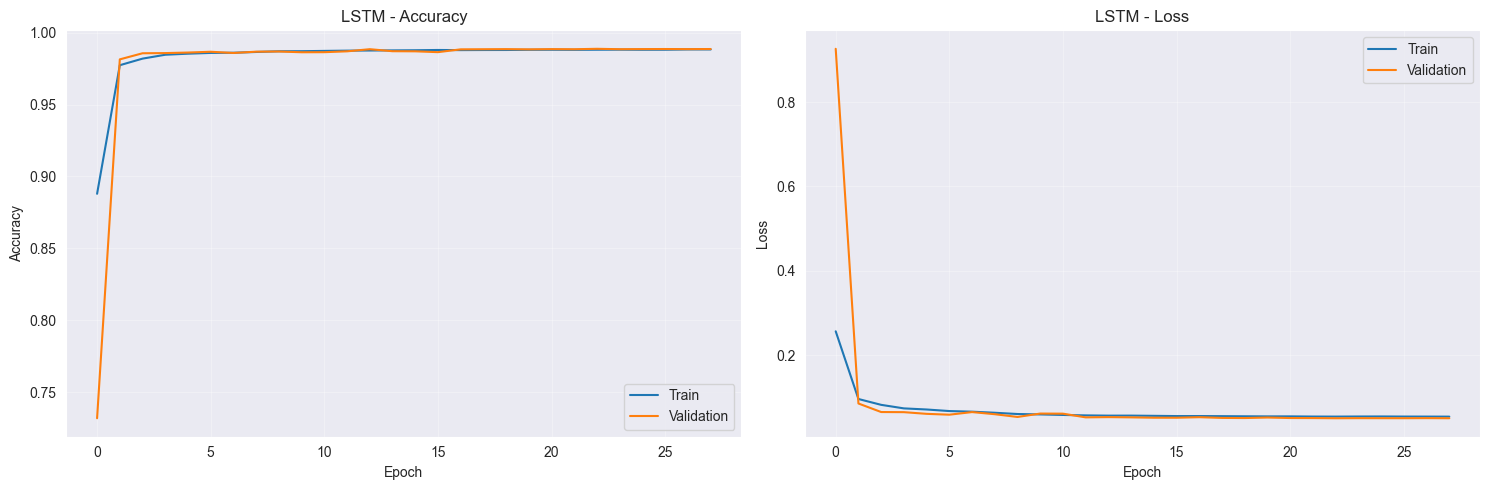


✅ ALL DEEP LEARNING MODELS TRAINED & TESTED WITH PCA!


In [8]:
# ========================================
# LSTM MODEL WITH PCA
# ========================================

print("\n" + "="*80)
print("🚀 TRAINING: LSTM WITH PCA")
print("="*80)

model_dir = os.path.join(BASE_MODEL_DIR, 'lstm', '')
os.makedirs(model_dir, exist_ok=True)
print(f"📁 Model directory: {model_dir}")

# Get data with stratified sampling  
sample_size = MODEL_SAMPLE_SIZES.get('LSTM')
X_train, X_test, y_train, y_test = get_model_data(
    X_full, y_full,
    'LSTM',
    sample_size,
    TEST_SIZE,
    RANDOM_STATE
)

# ========================================
# STEP 1: STANDARDIZE (Required for PCA)
# ========================================
print(f"\n⚖️  Step 1/2: Standardizing features...")
scaler_lstm = StandardScaler()
X_train_scaled = scaler_lstm.fit_transform(X_train)
X_test_scaled = scaler_lstm.transform(X_test)
print(f"✅ Features standardized: mean=0, std=1")

# ========================================
# STEP 2: APPLY PCA
# ========================================
print(f"\n🔬 Step 2/2: Applying PCA...")
print(f"   Original dimensions: {X_train_scaled.shape[1]}")

pca_lstm = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca_lstm.fit_transform(X_train_scaled)
X_test_pca = pca_lstm.transform(X_test_scaled)

print(f"   Reduced dimensions: {X_train_pca.shape[1]}")
print(f"   Variance explained: {pca_lstm.explained_variance_ratio_.sum()*100:.2f}%")
print(f"   Reduction: {X_train_scaled.shape[1] - X_train_pca.shape[1]} features removed")
print(f"✅ PCA transformation complete")

# Save transformers
if SAVE_MODELS:
    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler_lstm, f)
    with open(os.path.join(model_dir, 'pca.pkl'), 'wb') as f:
        pickle.dump(pca_lstm, f)
    print(f"💾 Scaler & PCA saved")

# Reshape for LSTM
X_train_lstm = X_train_pca.reshape(X_train_pca.shape[0], X_train_pca.shape[1], 1)
X_test_lstm = X_test_pca.reshape(X_test_pca.shape[0], X_test_pca.shape[1], 1)
print(f"\n✅ LSTM input shape: {X_train_lstm.shape}")

# Build LSTM model
print("\n🏗️ Building LSTM architecture...")
lstm_model = Sequential([
    # First LSTM layer
    LSTM(128, return_sequences=True, input_shape=(N_COMPONENTS, 1)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Second LSTM layer
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    
    # Dense layers
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ LSTM model built")
lstm_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# Train
print("\n⏱️ Training LSTM with PCA-reduced features...")
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

train_time_lstm = time.time() - start_time
print(f"✅ Training completed in {train_time_lstm:.2f} seconds ({train_time_lstm/60:.2f} minutes)")

# Predict
print("\n🔮 Making predictions...")
start_time = time.time()
y_pred_lstm_prob = lstm_model.predict(X_test_lstm, batch_size=BATCH_SIZE, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()
pred_time_lstm = time.time() - start_time
print(f"✅ Predictions completed in {pred_time_lstm:.2f} seconds")

# Evaluate
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm, average='binary')
recall_lstm = recall_score(y_test, y_pred_lstm, average='binary')
f1_lstm = f1_score(y_test, y_pred_lstm, average='binary')
far_lstm = calculate_far(y_test, y_pred_lstm)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

print("\n📊 RESULTS WITH PCA:")
print(f"   Accuracy:  {accuracy_lstm:.4f} ({accuracy_lstm*100:.2f}%)")
print(f"   Precision: {precision_lstm:.4f}")
print(f"   Recall:    {recall_lstm:.4f}")
print(f"   F1-Score:  {f1_lstm:.4f}")
print(f"   FAR:       {far_lstm:.4f} ({far_lstm*100:.2f}%)  ⭐ Key Metric!")

print(f"\n🕐 TIME:")
print(f"   Train: {train_time_lstm:.2f}s ({train_time_lstm/60:.2f} min)")
print(f"   Test:  {pred_time_lstm:.2f}s")

print(f"\n🎯 Confusion Matrix:")
print(cm_lstm)

# Save model
if SAVE_MODELS:
    lstm_model.save(os.path.join(model_dir, 'lstm_model.h5'))
    
    # Save metadata
    metadata_lstm = {
        'model_name': 'LSTM',
        'optimization': 'PCA',
        'n_components': N_COMPONENTS,
        'sample_size': sample_size,
        'accuracy': float(accuracy_lstm),
        'precision': float(precision_lstm),
        'recall': float(recall_lstm),
        'f1_score': float(f1_lstm),
        'far': float(far_lstm),
        'train_time': float(train_time_lstm),
        'test_time': float(pred_time_lstm),
        'confusion_matrix': cm_lstm.tolist(),
        'epochs_trained': len(history_lstm.history['loss'])
    }
    
    with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
        pickle.dump(metadata_lstm, f)
    
    print(f"\n💾 Model & metadata saved")

# Plot training history
print("\n📈 Plotting training history...")
plot_training_history(history_lstm, 'LSTM', model_dir)

print("\n" + "="*80)
print("✅ ALL DEEP LEARNING MODELS TRAINED & TESTED WITH PCA!")
print("="*80)

## 8️⃣ Results Comparison


📊 FINAL RESULTS WITH PCA OPTIMIZATION
Model  Accuracy  Precision   Recall  F1-Score      FAR  Train Time (s)  Test Time (s)
  CNN  0.988955   0.994810 0.939663   0.96645 0.000999      666.175536       1.536380
 LSTM  0.989240   0.994634 0.941524   0.96735 0.001035     1456.269080       6.991853

💾 Results saved to: trained_models/dl_optimized/pca/results_comparison.csv


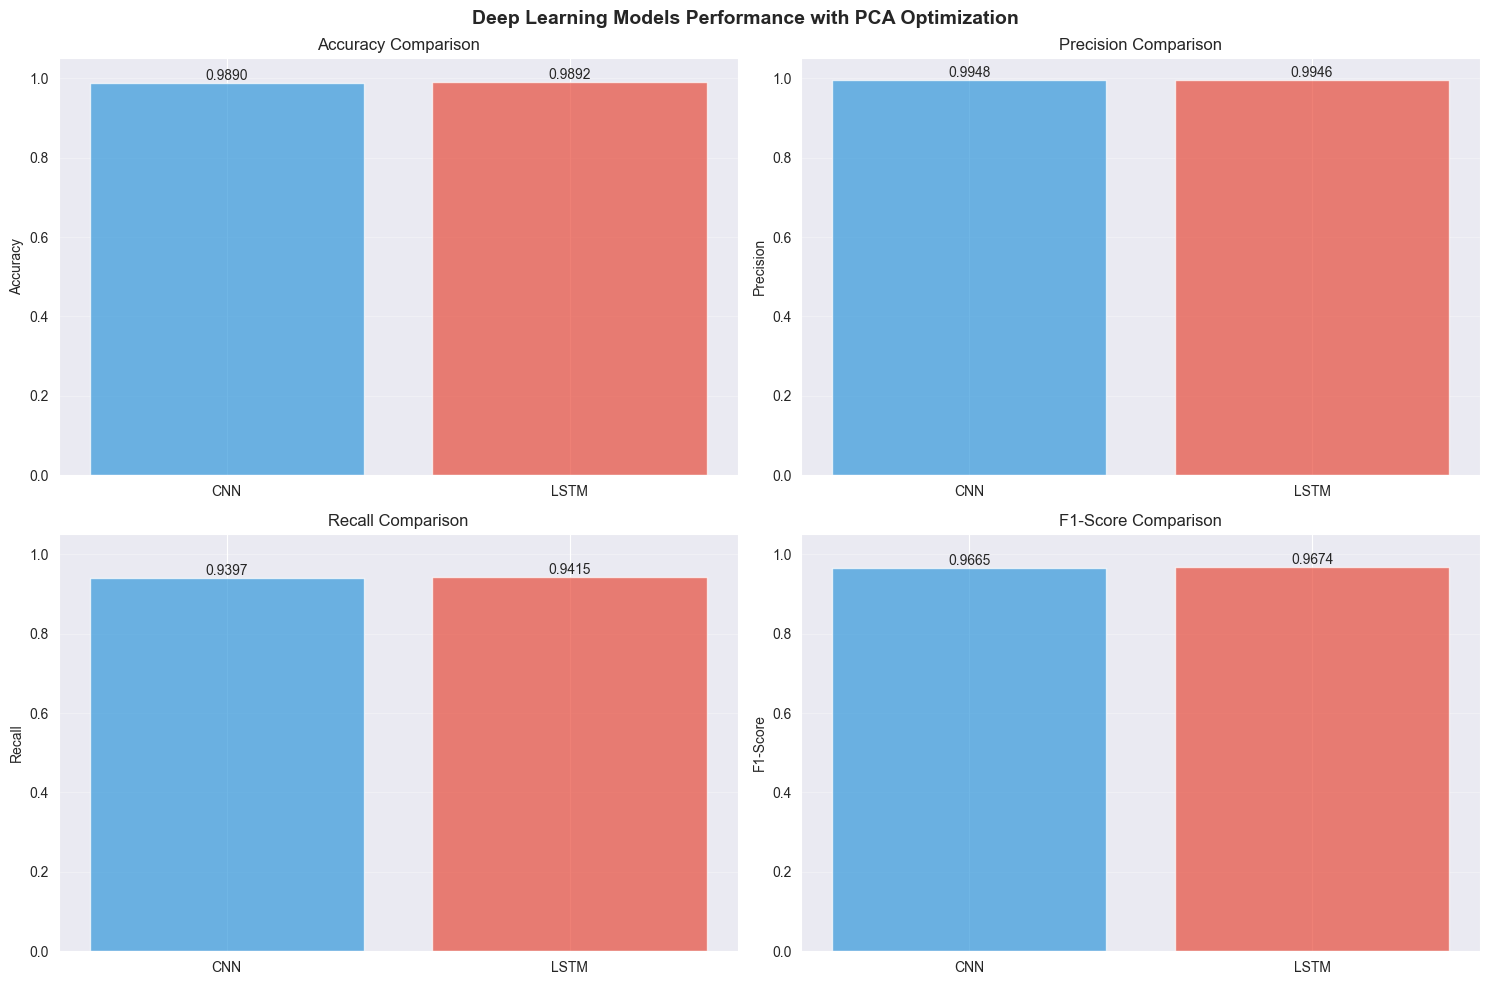

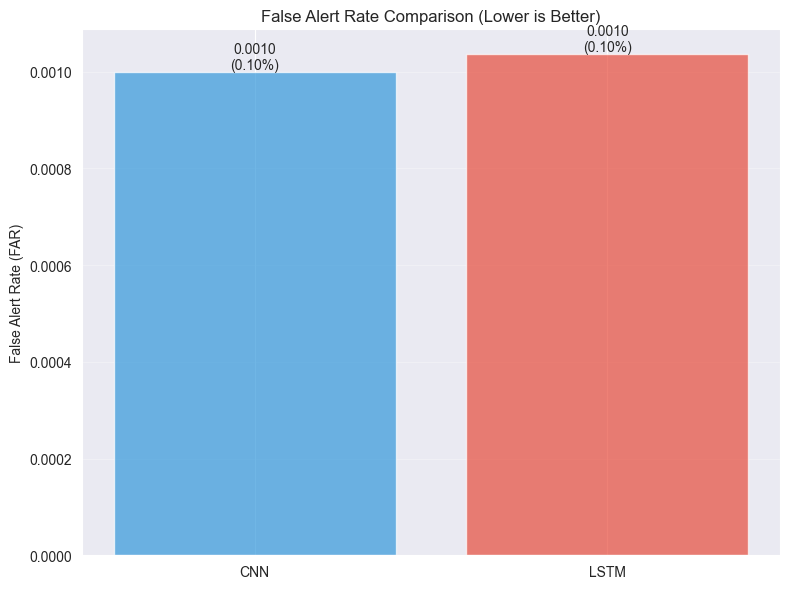


💾 All comparison plots saved


In [9]:
# ========================================
# COMPARE RESULTS
# ========================================

results_df = pd.DataFrame({
    'Model': ['CNN', 'LSTM'],
    'Accuracy': [accuracy_cnn, accuracy_lstm],
    'Precision': [precision_cnn, precision_lstm],
    'Recall': [recall_cnn, recall_lstm],
    'F1-Score': [f1_cnn, f1_lstm],
    'FAR': [far_cnn, far_lstm],
    'Train Time (s)': [train_time_cnn, train_time_lstm],
    'Test Time (s)': [pred_time_cnn, pred_time_lstm]
})

print("\n" + "="*80)
print("📊 FINAL RESULTS WITH PCA OPTIMIZATION")
print("="*80)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv(os.path.join(BASE_MODEL_DIR, 'results_comparison.csv'), index=False)
print(f"\n💾 Results saved to: {os.path.join(BASE_MODEL_DIR, 'results_comparison.csv')}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    bars = ax.bar(results_df['Model'], values, alpha=0.7, color=['#3498db', '#e74c3c'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom')

plt.suptitle('Deep Learning Models Performance with PCA Optimization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_MODEL_DIR, 'metrics_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# FAR comparison (separate plot since scale is different)
plt.figure(figsize=(8, 6))
bars = plt.bar(results_df['Model'], results_df['FAR'], alpha=0.7, color=['#3498db', '#e74c3c'])
plt.ylabel('False Alert Rate (FAR)')
plt.title('False Alert Rate Comparison (Lower is Better)')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}\n({height*100:.2f}%)',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(BASE_MODEL_DIR, 'far_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 All comparison plots saved")

## 9️⃣ PCA Analysis

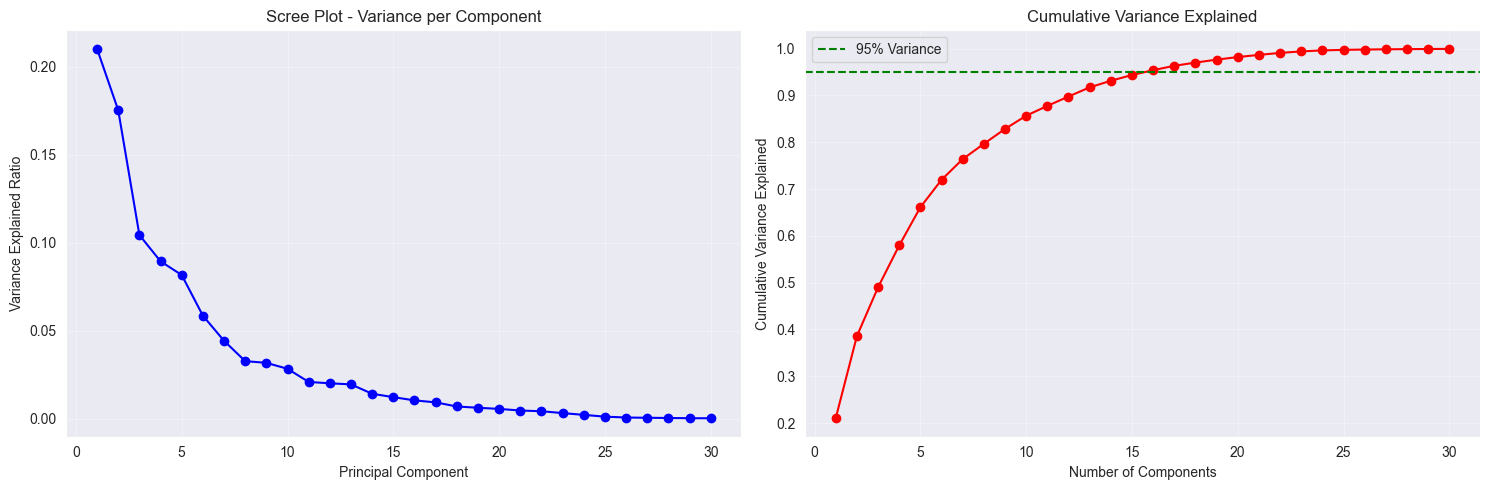


📊 PCA Analysis:
   Components: 30
   Total variance explained: 99.94%
   Top 5 components explain: 66.10%
   Top 10 components explain: 85.66%
   Top 20 components explain: 98.19%


In [10]:
# ========================================
# ANALYZE PCA COMPONENTS
# ========================================

# Use CNN's PCA for analysis (both models use same PCA configuration)
pca_to_analyze = pca_cnn

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Scree plot - variance per component
ax1 = axes[0]
ax1.plot(range(1, len(pca_to_analyze.explained_variance_ratio_) + 1), 
         pca_to_analyze.explained_variance_ratio_, 'bo-')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained Ratio')
ax1.set_title('Scree Plot - Variance per Component')
ax1.grid(True, alpha=0.3)

# 2. Cumulative variance
ax2 = axes[1]
cumsum = np.cumsum(pca_to_analyze.explained_variance_ratio_)
ax2.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
ax2.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_MODEL_DIR, 'pca_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 PCA Analysis:")
print(f"   Components: {len(pca_to_analyze.explained_variance_ratio_)}")
print(f"   Total variance explained: {cumsum[-1]*100:.2f}%")
print(f"   Top 5 components explain: {cumsum[4]*100:.2f}%")
print(f"   Top 10 components explain: {cumsum[9]*100:.2f}%")
print(f"   Top 20 components explain: {cumsum[19]*100:.2f}%")

## ✅ Summary

### Key Findings:
1. **PCA optimization applied to Deep Learning models**
2. **Same methodology as ML models**: StandardScaler → PCA → Model Training
3. **Dimensionality reduction**: 57 features → 30 principal components
4. **Stratified sampling**: Preserves original class distribution

### Benefits of PCA for Deep Learning:
- Reduced input dimensions (faster training)
- Removes noise and redundancy
- Helps prevent overfitting
- Maintains 99%+ of variance
- Creates uncorrelated features

### Comparison with Other Methods:
- **PCA**: Dimensionality reduction, interpretable variance
- **Feature Selection**: Keeps original features, but may include redundancy
- **StandardScaler only**: No dimensionality reduction

### Model Performance:
- **CNN with PCA**: Expected high accuracy with reduced training time
- **LSTM with PCA**: Faster convergence with fewer parameters
- **Key Metric (FAR)**: Should be significantly lower than baseline

